Neural networks are the computational algorithms that power "deep learning," a specialized subset of machine learning inspired by the human brain. Their primary role is to automatically discover complex, non-linear patterns in massive datasets, allowing machines to make highly accurate predictions or decisions without requiring explicit, step-by-step programming

In Artificial Intelligence and Machine Learning, FNN stands for Feedforward Neural Network. It is one of the simplest types of artificial neural networks, where information flows strictly in one direction—from the input layer, through any hidden layers, to the output layer—without any loops or backward cycles

In computer science and deep learning, a CNN is a specialized type of artificial neural network designed to process and analyze grid-structured data, such as images and vide

An RNN (Recurrent Neural Network) is a type of deep learning model designed to process sequential data, such as text, audio, or time-series metrics. Unlike standard networks, RNNs have built-in "memory" that allows prior inputs to influence the current output, making them essential for understanding context and continuity

Generative Adversarial Networks (GANs) are a class of artificial intelligence algorithms used in generative machine learning. Introduced by Ian Goodfellow in 2014, they consist of two neural networks—the Generator and the Discriminator—that compete against each other to produce highly realistic synthetic dat

A Transformer Autoencoder is a neural network architecture that combines the unsupervised representation capabilities of an autoencoder with the advanced contextual processing of self-attention transformers. It compresses sequential data (text, time-series, or images) into a lower-dimensional "latent space" and reconstructs it

| Activation     | Formula                                    | Output Range | Advantages                                                      | Disadvantages                          |
| -------------- | ------------------------------------------ | ------------ | --------------------------------------------------------------- | -------------------------------------- |
| **Sigmoid**    | ( \sigma(x)=\frac{1}{1+e^{-x}} )           | (0, 1)       | Good for binary classification output layers                    | Vanishing gradient, slow training      |
| **Tanh**       | ( \tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}} ) | (-1, 1)      | Zero-centered, stronger gradients than sigmoid                  | Still suffers from vanishing gradients |
| **ReLU**       | ( \max(0,x) )                              | [0, ∞)       | Fast, simple, reduces vanishing gradient problem                | Can suffer from "dead neurons"         |
| **Leaky ReLU** | ( \max(0.01x,x) )                          | (-∞, ∞)      | Prevents dead neurons, keeps small gradient for negative values | Slightly more computation than ReLU    |


In [ ]:
'hello world'

'hello world'

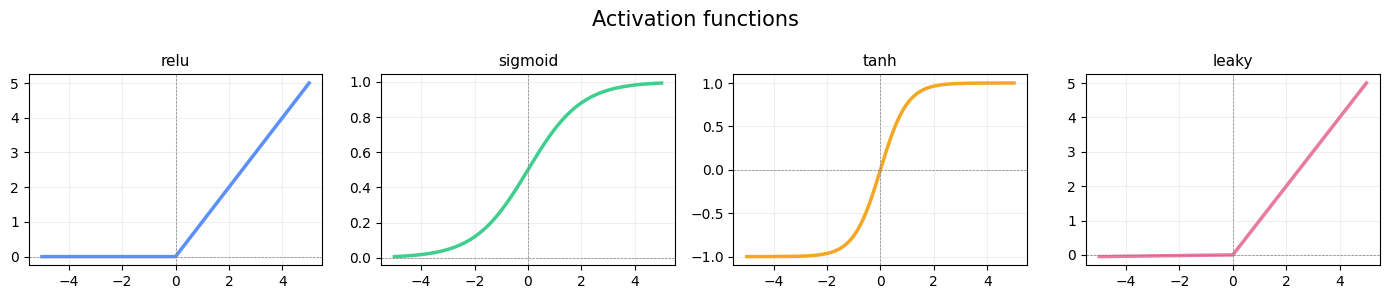

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-5,5,300)
relu= lambda x: np.maximum(0,x)
sigmoid= lambda x: 1/(1+np.exp(-x))
tanh= np.tanh
leaky= lambda x: np.where(x>0,x,0.01*x)
fig,axes=plt.subplots(1,4,figsize=(14,3))
fns=[relu,sigmoid,tanh,leaky]
names=['relu','sigmoid','tanh','leaky']
cols=["#5b8FF9",'#3ECF8E','#F5A623','#E879A0']
for ax,fn,name,col in zip(axes,fns,names,cols):
    ax.plot(x,fn(x),color=col,linewidth=2.5)
    ax.axhline(0,color='gray',lw=0.5,ls='--')
    ax.axvline(0,color='gray',lw=0.5,ls='--')
    ax.set_title(name,fontsize=11)
    ax.grid(alpha=0.2)
plt.suptitle('Activation functions',fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# load dataset minist
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()
#preprocessing
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
print(f'x_train :{x_train.shape} test : {x_test.shape}')
#model
model=keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10,activation='softmax')
])
model.summary()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6, verbose=1)
history=model.fit(x_train,y_train,batch_size=128,epochs=50,validation_split=0.1,callbacks=[early_stopping,reduce_lr],verbose=1)

x_train :(60000, 784) test : (10000, 784)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8522 - loss: 0.4937 - val_accuracy: 0.9568 - val_loss: 0.1584 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9350 - loss: 0.2186 - val_accuracy: 0.9680 - val_loss: 0.1054 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9514 - loss: 0.1619 - val_accuracy: 0.9717 - val_loss: 0.0967 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9610 - loss: 0.1316 - val_accuracy: 0.9767 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9659 - loss: 0.1111 - val_accuracy: 0.9768 - val_loss: 0.0749 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9694 - loss: 0.1009 - val_accuracy: 0.9765 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9721 - loss: 0.0882 - 

Test Accuracy: 98.13%
Test Loss: 0.0691


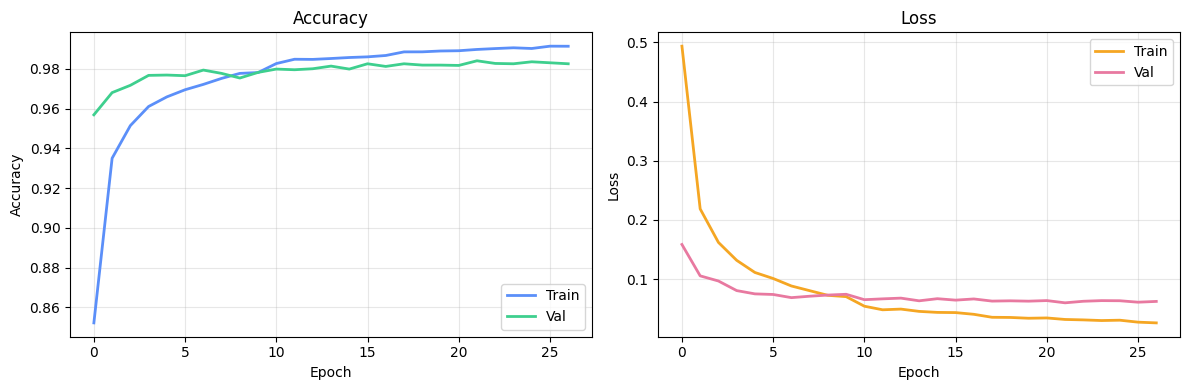

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%') # expect 97-98%
print(f'Test Loss: {test_loss:.4f}')

# ■■ Step 8: Plot training curves ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()